In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [211]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [212]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [213]:
df.tail(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13310,Super built-up Area,Ready To Move,Rachenahalli,2 BHK,NaN,1050,2.0,2.0,52.71
13311,Plot Area,Ready To Move,Ramamurthy Nagar,7 Bedroom,NaN,1500,9.0,2.0,250.00
13312,Super built-up Area,Ready To Move,Bellandur,2 BHK,NaN,1262,2.0,2.0,47.00
13313,Super built-up Area,Ready To Move,Uttarahalli,3 BHK,Aklia R,1345,2.0,1.0,57.00
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.00


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [216]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [217]:
df["area_type"].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [218]:
df["availability"].value_counts()

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

In [219]:
df["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1305, dtype: int64

In [220]:
df["location"].nunique

<bound method IndexOpsMixin.nunique of 0        Electronic City Phase II
1                Chikka Tirupathi
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
                   ...           
13315                  Whitefield
13316               Richards Town
13317       Raja Rajeshwari Nagar
13318             Padmanabhanagar
13319                Doddathoguru
Name: location, Length: 13320, dtype: str>

In [221]:
df["size"]=df["size"].str.replace("Bedroom","BHK",regex=False)

In [222]:
df["size"].isna().sum()


np.int64(16)

In [223]:
df.loc[df["size"].isna()]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
579,Plot Area,Immediate Possession,Sarjapur Road,NaN,Asiss B,1200 - 2400,NaN,NaN,34.185
1775,Plot Area,Immediate Possession,IVC Road,NaN,Orana N,2000 - 5634,NaN,NaN,124.000
2264,Plot Area,Immediate Possession,Banashankari,NaN,NaN,2400,NaN,NaN,460.000
2809,Plot Area,Immediate Possession,Sarjapur Road,NaN,AsdiaAr,1200 - 2400,NaN,NaN,28.785
2862,Plot Area,Immediate Possession,Devanahalli,NaN,Ajleyor,1500 - 2400,NaN,NaN,46.800
5333,Plot Area,Immediate Possession,Devanahalli,NaN,Emngs S,2100 - 5405,NaN,NaN,177.115
6423,Plot Area,Immediate Possession,Whitefield,NaN,SRniaGa,2324,NaN,NaN,26.730
6636,Plot Area,Immediate Possession,Jigani,NaN,S2enste,1500,NaN,NaN,25.490
6719,Plot Area,Immediate Possession,Hoskote,NaN,SJowsn,800 - 2660,NaN,NaN,28.545
7680,Plot Area,Immediate Possession,Kasavanhalli,NaN,NaN,5000,NaN,NaN,400.000


In [224]:
def extract_bhk_components(x):
    cols = ["bedrooms", "halls", "kitchens"]
    if pd.isna(x):
        return pd.Series([np.nan] * 3, index=cols)
    parts = str(x).strip().split()
    if not parts:
        return pd.Series([np.nan] * 3, index=cols)
    num = pd.to_numeric(parts[0], errors="coerce")
    unit = " ".join(parts[1:]).lower()
    if "rk" in unit:
        values = [0, 0, 1]
    elif any(k in unit for k in ["bhk", "bedroom"]):
        values = [num, 1, 1]
    else:
        values = [num, np.nan, np.nan]
    return pd.Series(values, index=cols)

In [225]:
df[["bedrooms", "halls", "kitchens"]] = df["size"].apply(extract_bhk_components)


In [226]:
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0,1.0,1.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 BHK,Theanmp,2600,5.0,3.0,120.00,4.0,1.0,1.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0,1.0,1.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3.0,1.0,1.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 BHK,ArsiaEx,3453,4.0,0.0,231.00,5.0,1.0,1.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00,4.0,1.0,1.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00,2.0,1.0,1.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00,4.0,1.0,1.0


In [227]:
df["balcony"] = df["balcony"].fillna(-1)


In [228]:
df.isna().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony            0
price              0
bedrooms          16
halls             16
kitchens          16
dtype: int64

In [250]:
df.loc[df["bath"].isna()]


,area_type,availability,location,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens


In [229]:
df["bath"] = df["bath"].fillna(-1)


In [230]:
df["bath"].isna().sum()


np.int64(0)

In [231]:
df.loc[df["location"].isna()]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0,3.0,1.0,1.0


In [232]:
df.loc[df["society"]=="Grare S"]


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bedrooms,halls,kitchens
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0,3.0,1.0,1.0
12238,Carpet Area,Ready To Move,Anantapura,3 BHK,Grare S,1600,3.0,2.0,77.0,3.0,1.0,1.0


In [233]:
df["location"]=df["location"].fillna("Anantapura")

In [234]:
df["location"].isnull().sum()

np.int64(0)

In [236]:
df["size"].isna().sum()


np.int64(16)

In [237]:
df = df[df["size"].notna()]


In [238]:
df["size"].isna().sum()


np.int64(0)

In [239]:
df.isna().sum()

area_type          0
availability       0
location           0
size               0
society         5499
total_sqft         0
bath               0
balcony            0
price              0
bedrooms           0
halls              0
kitchens           0
dtype: int64

In [240]:
df=df.drop("size",axis=1)


In [241]:
df["society"].isna().sum()/len(df)


np.float64(0.413334335538184)

In [ ]:
society_mode = df.groupby("location")["society"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)


In [244]:
df["society"] = df["society"].fillna(df["location"].map(society_mode))


In [245]:
df["society"].isna().sum()


np.int64(1413)

In [247]:
df["society"] = df["society"].fillna("unknown")


In [248]:
df["society"].isna().sum()


np.int64(0)

In [281]:
df.isna().sum()


area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
bedrooms        0
halls           0
kitchens        0
dtype: int64

In [259]:
df["total_sqft"].value_counts()


total_sqft
1200           843
1100           221
1500           204
2400           195
600            180
              ... 
1020 - 1130      1
2758             1
1133 - 1384      1
774              1
4689             1
Name: count, Length: 2110, dtype: int64

In [260]:
def clean_total_sqft(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    if "perch" in x.lower():
        num_str = x.lower().replace("perch", "").strip()
        return pd.to_numeric(num_str) * 272.25
    if "sq. yards" in x.lower():
        num_str = x.lower().replace("sq. yards", "").strip()
        return pd.to_numeric(num_str) * 9.0
    if "acre" in x.lower():
        num_str = x.lower().replace("acres", "").replace("acre", "").strip()
        return pd.to_numeric(num_str) * 43560.0
    if "sq. meter" in x.lower():
        num_str = x.lower().replace("sq. meter", "").strip()
        return pd.to_numeric(num_str) * 10.7639
    if "cent" in x.lower():
        num_str = x.lower().replace("cents", "").replace("cent", "").strip()
        return pd.to_numeric(num_str) * 435.6
    if "ground" in x.lower():
        num_str = x.lower().replace("grounds", "").replace("ground", "").strip()
        return pd.to_numeric(num_str) * 2400.0
    if "guntha" in x.lower():
        num_str = x.lower().replace("guntha", "").strip()
        return pd.to_numeric(num_str) * 1089.0
    if "-" in x:
        parts = x.split("-")
        v1 = pd.to_numeric(parts[0].strip())
        v2 = pd.to_numeric(parts[1].strip())
        return (v1 + v2) / 2.0
    return pd.to_numeric(x)



In [261]:
df["total_sqft"] = df["total_sqft"].apply(clean_total_sqft)


In [262]:
df["total_sqft"].value_counts()


total_sqft
1200.0    843
1100.0    221
1500.0    204
2400.0    196
600.0     180
         ... 
2395.0      1
2758.0      1
1258.5      1
774.0       1
4689.0      1
Name: count, Length: 2031, dtype: int64

In [263]:
num_cols=['total_sqft', 'bath', 'balcony', 'price','bedrooms', 'halls','kitchens']
text_cols=['area_type', 'availability', 'location', 'society']



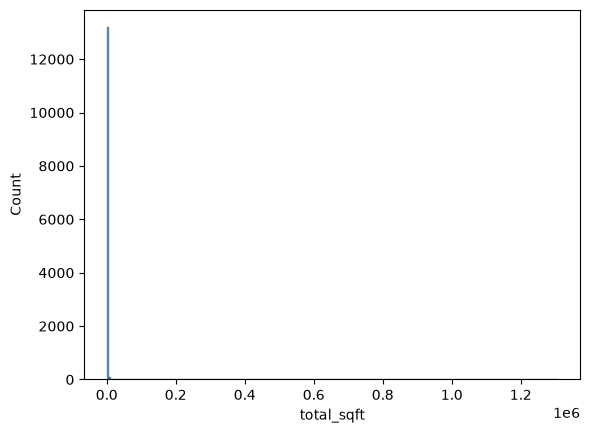

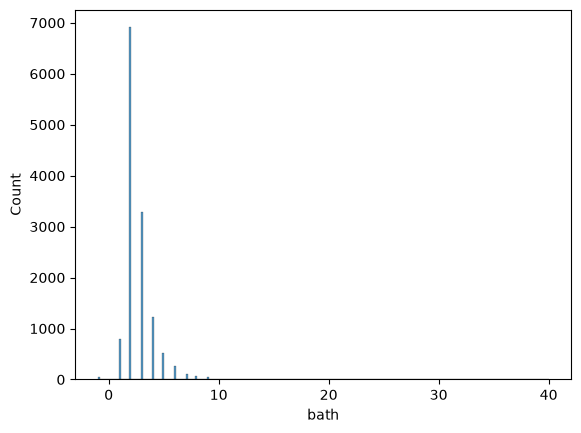

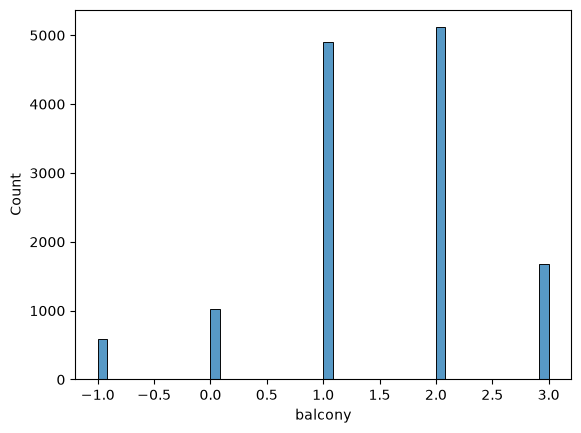

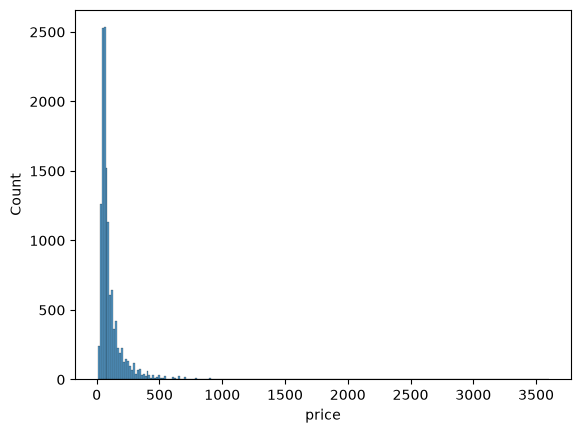

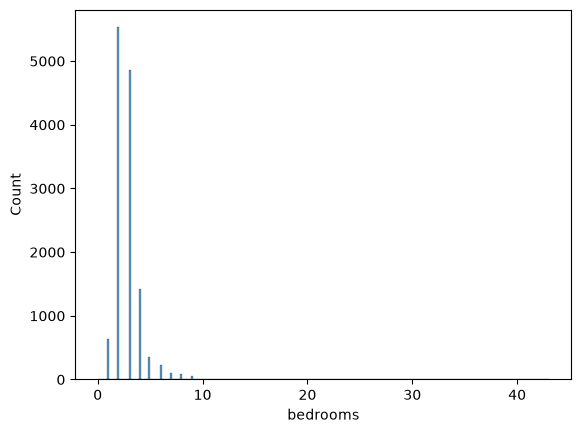

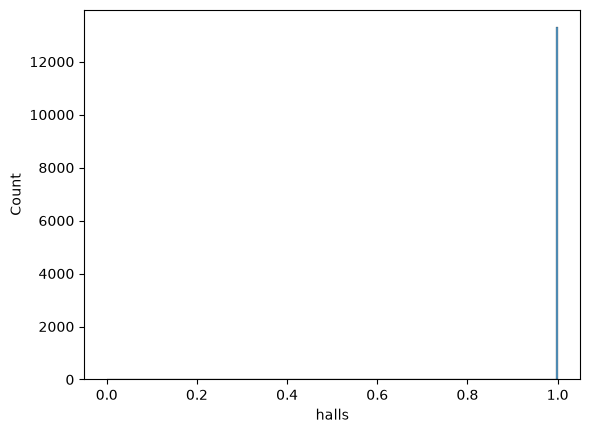

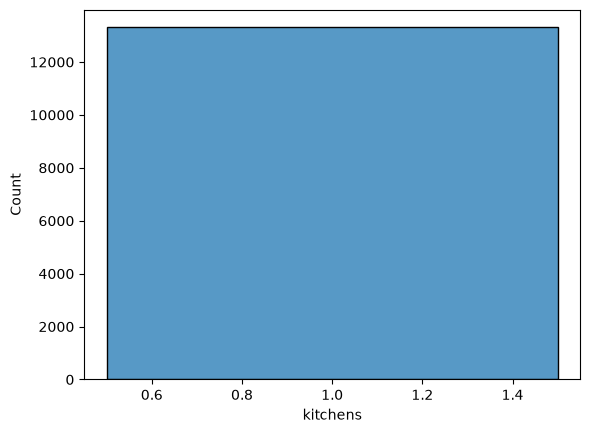

In [265]:
for i in num_cols:
    plt.figure()
    sns.histplot(df[i])


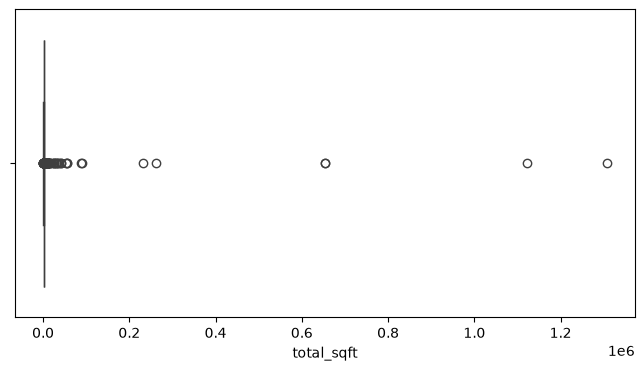

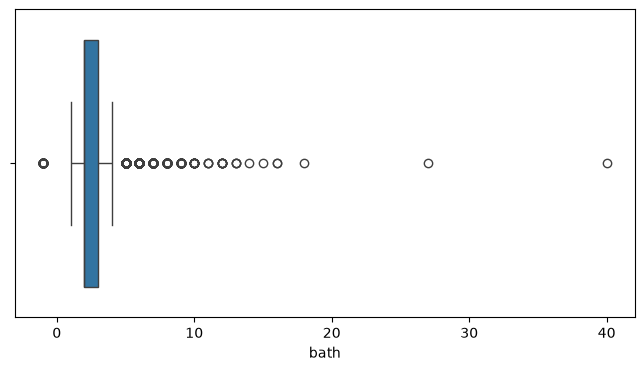

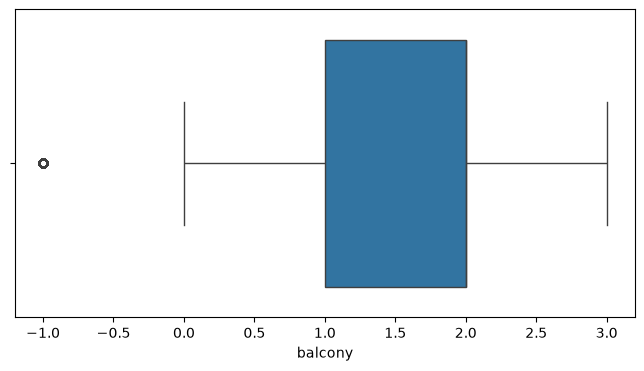

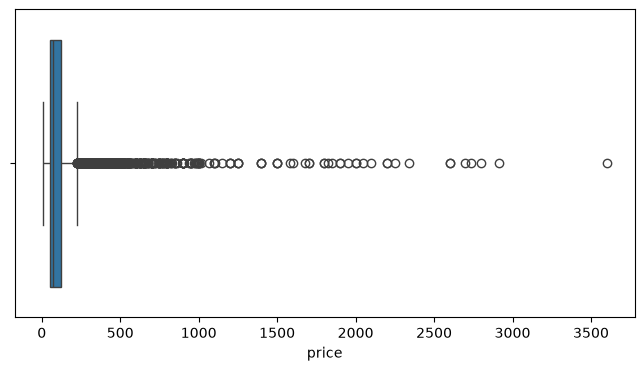

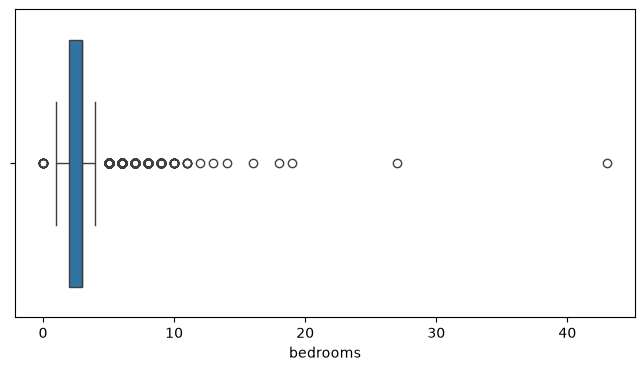

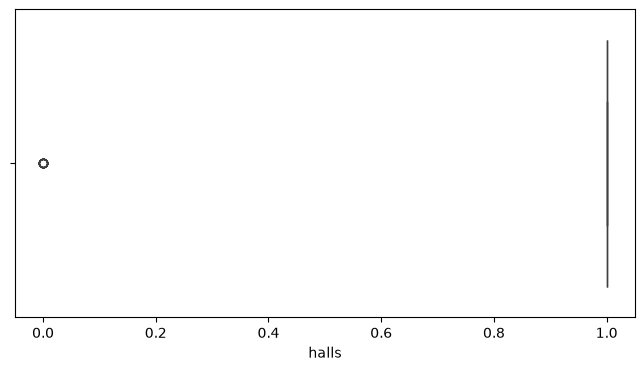

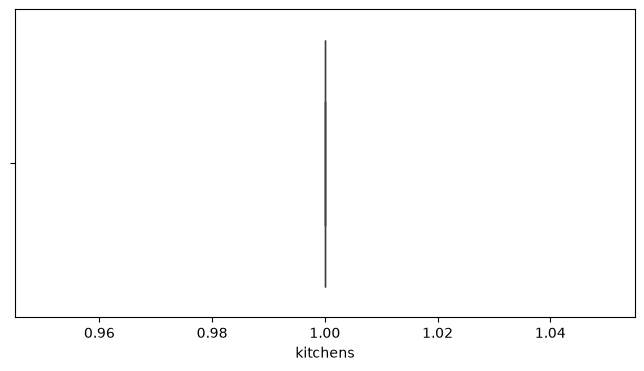

In [268]:
for i in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.show()

In [270]:
df[["price","total_sqft","bath","bedrooms","halls","kitchens"]].describe()

,price,total_sqft,bath,bedrooms,halls,kitchens
count,13304.000000,1.330400e+04,13304.000000,13304.000000,13304.000000,13304.0
mean,112.582035,1.911209e+03,2.676789,2.802766,0.999023,1.0
std,148.988398,1.728725e+04,1.360137,1.296711,0.031245,0.0
min,8.000000,1.000000e+00,-1.000000,0.000000,0.000000,1.0
25%,50.000000,1.100000e+03,2.000000,2.000000,1.000000,1.0
50%,72.000000,1.276000e+03,2.000000,3.000000,1.000000,1.0
75%,120.000000,1.680000e+03,3.000000,3.000000,1.000000,1.0
max,3600.000000,1.306800e+06,40.000000,43.000000,1.000000,1.0


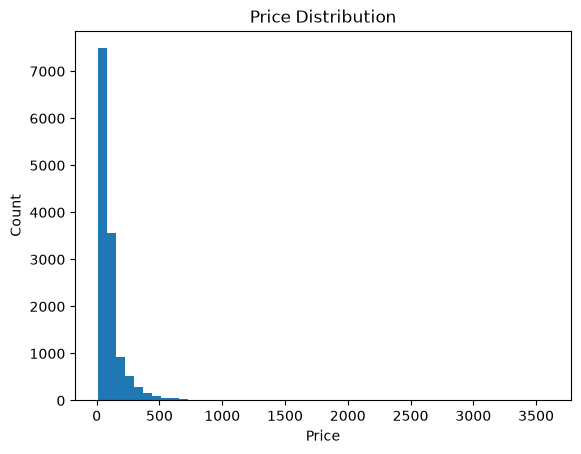

In [272]:
plt.hist(df["price"],bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Sqft vs Price Distribution

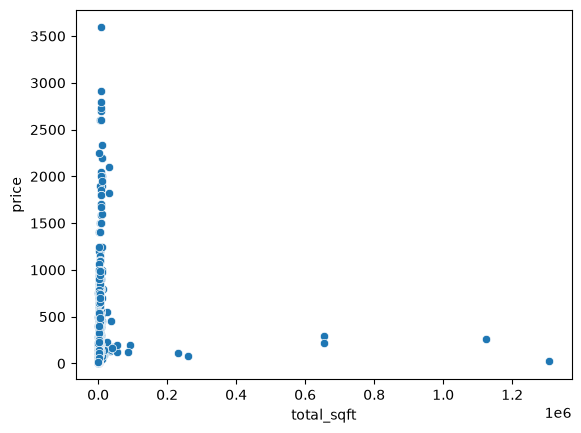

In [275]:
sns.scatterplot(data=df,x="total_sqft",y="price")
plt.show()


In [278]:
df[["bedrooms", "halls", "kitchens"]] = df[["bedrooms", "halls", "kitchens"]].astype(int)


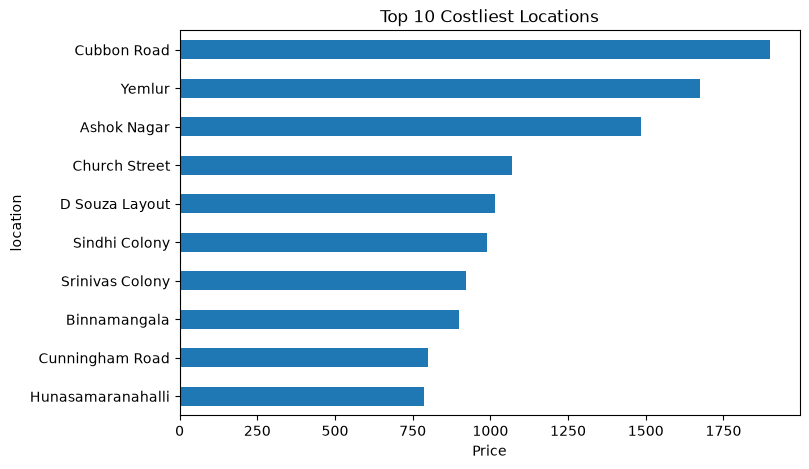

In [293]:
top = df[df["location"] != "other"].groupby("location")["price"].median().nlargest(10)
top.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 Costliest Locations")
plt.xlabel("Price")
plt.show()

In [283]:
df[["bedrooms", "price"]].describe()

,bedrooms,price
count,13304.000000,13304.000000
mean,2.802766,112.582035
std,1.296711,148.988398
min,0.000000,8.000000
25%,2.000000,50.000000
50%,3.000000,72.000000
75%,3.000000,120.000000
max,43.000000,3600.000000


In [284]:
df[df["bedrooms"] > 10][["bedrooms", "price", "total_sqft", "location"]]

,bedrooms,price,total_sqft,location
459,11,360.0,5000.0,1 Giri Nagar
1718,27,230.0,8000.0,2Electronic City Phase II
1768,11,170.0,1200.0,1 Ramamurthy Nagar
3379,19,490.0,2000.0,1Hanuman Nagar
3609,16,550.0,10000.0,Koramangala Industrial Layout
3853,11,150.0,1200.0,1 Annasandrapalya
4684,43,660.0,2400.0,Munnekollal
4916,14,125.0,1250.0,1Channasandra
6533,12,300.0,2232.0,Mysore Road
7979,11,150.0,6000.0,1 Immadihalli


In [285]:
df = df[df["bedrooms"] <= 10]

In [286]:
df["bedrooms"].max()

np.int64(10)

In [287]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
lower, upper

(np.float64(-55.0), np.float64(225.0))

In [290]:
print("Upper limit:", upper)
print("Number of outliers:", (df["price"] > upper).sum())

Upper limit: 225.0
Number of outliers: 1267


In [291]:
df["price"].max()

np.float64(3600.0)

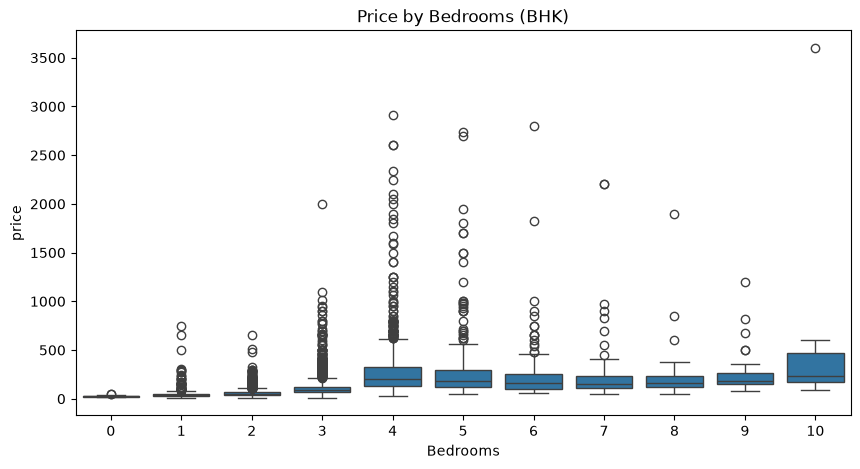

In [292]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="bedrooms", y="price")
plt.title("Price by Bedrooms (BHK)")
plt.xlabel("Bedrooms")
plt.show()

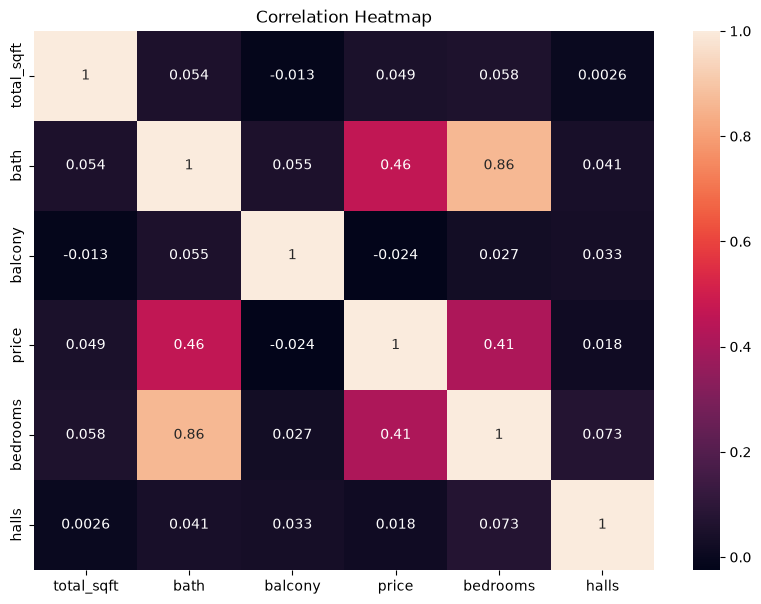

In [298]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[["total_sqft", "bath", "balcony", "price", "bedrooms", "halls"]].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [300]:
df[["bedrooms", "halls", "kitchens","location","price","bath","total_sqft","balcony"]].isna().sum()


bedrooms      0
halls         0
kitchens      0
location      0
price         0
bath          0
total_sqft    0
balcony       0
dtype: int64

In [306]:
model_df=df[["bedrooms", "halls", "kitchens","location","price","bath","total_sqft","balcony"]].copy()


In [307]:

model_df = pd.get_dummies(model_df, columns=["location"], drop_first=True)

In [308]:
X = model_df.drop("price", axis=1)
y = model_df["price"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [310]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1300,)","[13.36, 7.23, 0. ,..., 2.04, 0. , 2.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1300,)","['bedrooms','halls','kitchens',...,'location_vinayakanagar', 'location_white field,kadugodi','location_whitefiled']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.785
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1300
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(564)


In [311]:
y_pred = model.predict(X_test)

In [312]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.3695517463575231
MAE: 53.04499959182567
RMSE: 136.4180273179047


In [313]:
comparison = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})
comparison.head(10)

,Actual Price,Predicted Price
0,53.00,50.490470
1,90.00,134.365734
2,50.74,76.324582
3,40.00,57.770379
4,53.60,89.321066
5,77.00,90.359855
6,130.00,202.358436
7,41.50,63.074631
8,350.00,403.104637
9,50.00,51.794039
